# Safety operations metrics

Reads the `safety_ops.*` SQL views (`analytics/sql/safety_ops_views.sql`, applied with
`npm run analytics:views`) and writes up what the report, dispute and vetting history shows.
The SQL views are the source of truth; this notebook only reads them and draws.

**Metrics covered:** report volume by category and week, median time to resolution, dismissal
rate by reason, users with two or more reports, Garda vetting approval rate, dispute refund
rate, and outcomes of the automated message screener.

**If real volume is thin** (fewer than `MIN_REPORTS` rows in `safety_ops.reports`, or no
database reachable) the notebook generates a **synthetic** 18-month history with the same
schema and says so loudly. The synthetic history is for exercising the metrics and the
write-up, not for decisions.

Run: `cd findgrinds-backend && DATABASE_URL=postgres://... .venv/Scripts/jupyter nbconvert --execute --to notebook --inplace analytics/safety_ops_metrics.ipynb`

In [1]:
import os, warnings
from pathlib import Path
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

MIN_REPORTS = 200          # below this, weekly trends are noise
NOW = datetime.now(timezone.utc).replace(minute=0, second=0, microsecond=0)

# Chart chrome: thin marks, recessive grid, ink for text. Series colours are the
# validated categorical slots (adjacent-pair CVD safe); one hue per single-series chart.
SURFACE, INK, INK2, MUTED, GRID, BASELINE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # blue, orange, aqua, yellow
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "axes.titlecolor": INK, "axes.titleweight": "bold", "axes.titlesize": 11, "axes.titlelocation": "left",
    "font.family": "sans-serif", "font.size": 9.5, "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2, "lines.markersize": 6, "figure.dpi": 110,
})

def date_axis(ax, months=3):
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=months))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

def database_url():
    url = os.environ.get("DATABASE_URL")
    if url:
        return url
    for p in (Path(".env"), Path("..") / ".env"):
        if p.exists():
            for line in p.read_text(encoding="utf-8").splitlines():
                if line.startswith("DATABASE_URL="):
                    return line.split("=", 1)[1].strip().strip('"').strip("'")
    return None

In [2]:
SOURCE, WHY, engine = "synthetic", "", None
url = database_url()
if not url:
    WHY = "DATABASE_URL is not set and no .env was found"
else:
    try:
        import sqlalchemy as sa
        engine = sa.create_engine(url.replace("postgresql://", "postgresql+psycopg://", 1))
        with engine.connect() as con:
            n_reports = con.execute(sa.text("SELECT count(*) FROM safety_ops.reports")).scalar()
        dbname = url.rsplit("/", 1)[-1].split("?")[0]
        if n_reports >= MIN_REPORTS:
            SOURCE = "database"
            WHY = f"{n_reports} reports in safety_ops.reports on database '{dbname}'"
        else:
            WHY = f"only {n_reports} report(s) in safety_ops.reports on database '{dbname}' (need {MIN_REPORTS}+ for trends)"
    except Exception as e:  # missing schema, no server, bad credentials
        WHY = f"could not read the safety_ops views ({type(e).__name__})"

banner = (f"### Data source: **REAL** - {WHY}" if SOURCE == "database" else
          f"### Data source: **SYNTHETIC** - {WHY}.\n\nEvery number and chart below is generated, seeded "
          f"history with realistic structure. It exercises the metrics and the write-up; it is **not** evidence about FindGrinds.")
display(Markdown(banner))

### Data source: **SYNTHETIC** - could not read the safety_ops views (ProgrammingError).

Every number and chart below is generated, seeded history with realistic structure. It exercises the metrics and the write-up; it is **not** evidence about FindGrinds.

## Synthetic history (used only when real volume is thin)

Same columns as the views. Built-in structure, so the metrics have something to find:
volume grows over 18 months with back-to-school and pre-exam peaks; resolution time
improves over time; dismissal rates differ by reason (spam mostly dismissed, safety
concerns rarely); a small set of users attracts a large share of reports; the automated
screener switches on part-way through; vetting approvals hover in the high 80s%;
dispute refund rates differ by reason.

In [3]:
def synthetic_history(seed=20260917, weeks=78, now=NOW):
    rng = np.random.default_rng(seed)
    start = now - timedelta(weeks=weeks)
    screener_launch = now - timedelta(weeks=13)

    type_p = {"message": 0.45, "dispute": 0.25, "resource": 0.18, "review": 0.12}
    reasons = {
        "message":  (["inappropriate", "harassment", "spam", "safety_concern", "other"], [0.28, 0.17, 0.33, 0.13, 0.09]),
        "dispute":  (["tutor_no_show", "poor_quality", "inappropriate_behavior", "other"], [0.40, 0.35, 0.08, 0.17]),
        "review":   (["inappropriate", "harassment", "false_claims", "other"], [0.30, 0.20, 0.40, 0.10]),
        "resource": (["misleading_content", "poor_quality", "wrong_subject", "incomplete", "other"], [0.30, 0.35, 0.15, 0.15, 0.05]),
    }
    dismiss_p = {"spam": 0.62, "other": 0.50, "inappropriate": 0.30, "harassment": 0.22, "safety_concern": 0.12,
                 "off_platform_contact": 0.35, "tutor_no_show": 0.33, "poor_quality": 0.55, "inappropriate_behavior": 0.18,
                 "false_claims": 0.45, "misleading_content": 0.40, "wrong_subject": 0.35, "incomplete": 0.45}
    median_hours = {"message": 30, "dispute": 72, "review": 48, "resource": 36}

    tutors = [f"tutor-{i:04d}" for i in range(400)]
    students = [f"student-{i:04d}" for i in range(1500)]
    # a small set of tutors attract a large share of reports
    tutor_w = np.ones(len(tutors)); tutor_w[:20] = 25; tutor_w /= tutor_w.sum()
    student_w = np.ones(len(students)); student_w[:40] = 12; student_w /= student_w.sum()

    rows = []
    for w in range(weeks):
        week_start = start + timedelta(weeks=w)
        month = week_start.month
        season = 1.0 + (0.45 if month in (9, 10) else 0.35 if month in (4, 5) else -0.35 if month in (7, 8) else -0.2 if month == 12 else 0.0)
        growth = 6 + 16 * (w / weeks)
        n = rng.poisson(max(1.0, growth * season))
        for _ in range(n):
            rtype = rng.choice(list(type_p), p=list(type_p.values()))
            rs, ps = reasons[rtype]
            reason = rng.choice(rs, p=ps)
            created = week_start + timedelta(hours=float(rng.uniform(0, 24 * 7)))
            subject = rng.choice(tutors, p=tutor_w) if rtype in ("message", "dispute", "resource") else rng.choice(students, p=student_w)
            reporter = rng.choice(students) if rtype != "review" else rng.choice(tutors)
            improve = 1 - 0.35 * (w / weeks)
            hours = float(rng.lognormal(np.log(median_hours[rtype] * improve), 0.8))
            reviewed = created + timedelta(hours=hours)
            if reviewed > now:
                status, resolution, reviewed = "PENDING", "open", pd.NaT
            elif rng.random() < dismiss_p.get(reason, 0.4):
                status, resolution = "DISMISSED", "dismissed"
            else:
                status, resolution = ("REFUNDED" if rtype in ("dispute", "resource") else "REVIEWED"), "actioned"
            rows.append(dict(report_type=rtype, reason=reason, status=status, resolution=resolution, source="user",
                             reporter_id=reporter, subject_user_id=subject, created_at=created, reviewed_at=reviewed,
                             score=np.nan, price=float(rng.choice([30, 35, 40, 45, 50, 60])) if rtype == "dispute" else np.nan,
                             tutor_response=(rng.random() < 0.7) if rtype == "dispute" else False))
        # automated screener: tutor -> minor messages, from launch
        if week_start >= screener_launch:
            for _ in range(rng.poisson(4.5)):
                created = week_start + timedelta(hours=float(rng.uniform(0, 24 * 7)))
                hours = float(rng.lognormal(np.log(20), 0.7))
                reviewed = created + timedelta(hours=hours)
                if reviewed > now:
                    status, resolution, reviewed = "PENDING", "open", pd.NaT
                elif rng.random() < dismiss_p["off_platform_contact"]:
                    status, resolution = "DISMISSED", "dismissed"
                else:
                    status, resolution = "REVIEWED", "actioned"
                rows.append(dict(report_type="message", reason="off_platform_contact", status=status, resolution=resolution,
                                 source="auto_screening", reporter_id=None, subject_user_id=rng.choice(tutors, p=tutor_w),
                                 created_at=created, reviewed_at=reviewed, score=float(rng.uniform(0.5, 0.98)), price=np.nan, tutor_response=False))
    reports = pd.DataFrame(rows)
    reports["report_id"] = [f"r-{i:06d}" for i in range(len(reports))]
    reports["created_at"] = pd.to_datetime(reports["created_at"], utc=True)
    reports["reviewed_at"] = pd.to_datetime(reports["reviewed_at"], utc=True)
    reports["hours_to_resolution"] = (reports["reviewed_at"] - reports["created_at"]).dt.total_seconds() / 3600
    reports["user_type"] = np.where(reports["subject_user_id"].str.startswith("tutor"), "TUTOR", "STUDENT")

    # Garda vetting submissions per month
    vrows = []
    for m in range(18):
        month_start = (now.replace(day=1) - pd.DateOffset(months=17 - m)).to_pydatetime()
        for _ in range(rng.poisson(10 + 25 * m / 17)):
            submitted = month_start + timedelta(days=float(rng.uniform(0, 28)))
            hours = float(rng.lognormal(np.log(60 * (1 - 0.3 * m / 17)), 0.6))
            reviewed = submitted + timedelta(hours=hours)
            if reviewed > now:
                vrows.append(dict(submitted_at=submitted, status="PENDING", reviewed_at=pd.NaT))
            else:
                vrows.append(dict(submitted_at=submitted, status="APPROVED" if rng.random() < 0.87 else "REJECTED", reviewed_at=reviewed))
    vetting = pd.DataFrame(vrows)
    vetting["submitted_at"] = pd.to_datetime(vetting["submitted_at"], utc=True)
    vetting["reviewed_at"] = pd.to_datetime(vetting["reviewed_at"], utc=True)
    return reports, vetting

def metrics_from_frames(reports, vetting):
    r = reports.copy()
    r["week_start"] = r["created_at"].dt.tz_localize(None).dt.to_period("W-SUN").dt.start_time
    r["month"] = r["created_at"].dt.tz_localize(None).dt.to_period("M").dt.start_time
    resolved = r[r["resolution"] != "open"]
    m = {}
    m["report_volume_weekly"] = (r.groupby(["week_start", "report_type", "reason", "source"]).agg(
        reports=("report_id", "size"), still_open=("resolution", lambda s: (s == "open").sum()),
        actioned=("resolution", lambda s: (s == "actioned").sum()), dismissed=("resolution", lambda s: (s == "dismissed").sum())).reset_index())
    m["resolution_time"] = r.groupby("report_type").apply(lambda g: pd.Series(dict(
        resolved=(g["resolution"] != "open").sum(), open=(g["resolution"] == "open").sum(),
        median_hours=g.loc[g["resolution"] != "open", "hours_to_resolution"].median(),
        p90_hours=g.loc[g["resolution"] != "open", "hours_to_resolution"].quantile(0.9),
        oldest_open_hours=((NOW - g.loc[g["resolution"] == "open", "created_at"]).dt.total_seconds() / 3600).max())), include_groups=False).reset_index()
    m["resolution_time_monthly"] = resolved.groupby(["month", "report_type"])["hours_to_resolution"].agg(
        resolved="size", median_hours="median", p90_hours=lambda s: s.quantile(0.9)).reset_index()
    d = r.groupby(["report_type", "reason"]).agg(reports=("report_id", "size"),
        resolved=("resolution", lambda s: (s != "open").sum()), dismissed=("resolution", lambda s: (s == "dismissed").sum()),
        actioned=("resolution", lambda s: (s == "actioned").sum())).reset_index()
    d["dismissal_rate"] = (d["dismissed"] / d["resolved"].replace(0, np.nan)).round(3)
    m["dismissal_rate"] = d
    u = r.groupby(["subject_user_id", "user_type"]).agg(reports=("report_id", "size"), report_types=("report_type", "nunique"),
        distinct_reporters=("reporter_id", "nunique"), actioned=("resolution", lambda s: (s == "actioned").sum()),
        open=("resolution", lambda s: (s == "open").sum()), first_reported_at=("created_at", "min"), last_reported_at=("created_at", "max")).reset_index()
    m["repeat_reported_users"] = u[u["reports"] >= 2].rename(columns={"subject_user_id": "user_id"})
    v = vetting.copy(); v["month"] = v["submitted_at"].dt.tz_localize(None).dt.to_period("M").dt.start_time
    v["review_hours"] = (v["reviewed_at"] - v["submitted_at"]).dt.total_seconds() / 3600
    vv = v.groupby("month").agg(submitted=("status", "size"), approved=("status", lambda s: (s == "APPROVED").sum()),
        rejected=("status", lambda s: (s == "REJECTED").sum()), pending=("status", lambda s: (s == "PENDING").sum()),
        median_review_hours=("review_hours", "median")).reset_index()
    vv["approval_rate"] = (vv["approved"] / (vv["approved"] + vv["rejected"]).replace(0, np.nan)).round(3)
    m["vetting_approval_rate"] = vv
    disp = r[r["report_type"] == "dispute"]
    dd = disp.groupby(["month", "reason"]).agg(disputes=("report_id", "size"), refunded=("status", lambda s: (s == "REFUNDED").sum()),
        dismissed=("status", lambda s: (s == "DISMISSED").sum()), pending=("status", lambda s: (s == "PENDING").sum()),
        with_tutor_response=("tutor_response", "sum")).reset_index()
    dd["refund_rate"] = (dd["refunded"] / (dd["disputes"] - dd["pending"]).replace(0, np.nan)).round(3)
    dd["refunded_value_eur"] = disp[disp["status"] == "REFUNDED"].groupby(["month", "reason"])["price"].sum().reindex(
        pd.MultiIndex.from_frame(dd[["month", "reason"]])).fillna(0).values
    m["dispute_refund_rate"] = dd
    auto = r[r["source"] == "auto_screening"]
    so = auto.groupby("week_start").agg(flagged=("report_id", "size"), confirmed=("status", lambda s: (s == "REVIEWED").sum()),
        dismissed=("status", lambda s: (s == "DISMISSED").sum()), open=("status", lambda s: (s == "PENDING").sum()), avg_score=("score", "mean")).reset_index()
    so["confirmed_rate"] = (so["confirmed"] / (so["flagged"] - so["open"]).replace(0, np.nan)).round(3)
    m["screening_outcomes"] = so
    return m

VIEWS = ["report_volume_weekly", "resolution_time", "resolution_time_monthly", "dismissal_rate",
         "repeat_reported_users", "vetting_approval_rate", "dispute_refund_rate", "screening_outcomes"]
if SOURCE == "database":
    M = {v: pd.read_sql(f"SELECT * FROM safety_ops.{v}", engine) for v in VIEWS}
    for v in ("report_volume_weekly", "screening_outcomes"):
        M[v]["week_start"] = pd.to_datetime(M[v]["week_start"])
    for v in ("resolution_time_monthly", "vetting_approval_rate", "dispute_refund_rate"):
        M[v]["month"] = pd.to_datetime(M[v]["month"])
else:
    REPORTS, VETTING = synthetic_history()
    M = metrics_from_frames(REPORTS, VETTING)
    print(f"synthetic: {len(REPORTS)} reports over {REPORTS['created_at'].min():%Y-%m-%d} .. {REPORTS['created_at'].max():%Y-%m-%d}, {len(VETTING)} vetting submissions")
{v: M[v].shape for v in VIEWS}

synthetic: 1159 reports over 2025-03-20 .. 2026-09-16, 415 vetting submissions


{'report_volume_weekly': (657, 8),
 'resolution_time': (4, 6),
 'resolution_time_monthly': (76, 5),
 'dismissal_rate': (19, 7),
 'repeat_reported_users': (137, 9),
 'vetting_approval_rate': (18, 7),
 'dispute_refund_rate': (64, 9),
 'screening_outcomes': (14, 7)}

## 1. Report volume by category and week

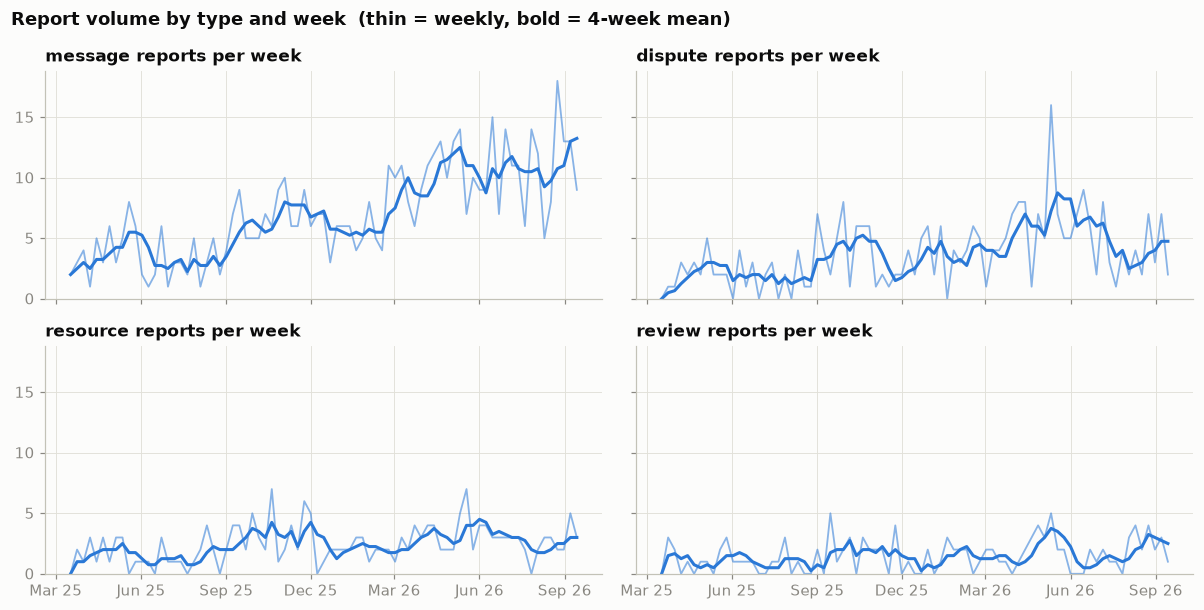

weeks: 79   mean/week: 14.7   last 4 weeks/week: 23.5   peak: 2026-05-11 (40 reports)


reports  share
report_type reason                              
message     spam                      175  0.191
dispute     tutor_no_show             130  0.142
message     inappropriate             127  0.138
dispute     poor_quality               97  0.106
message     harassment                 93  0.101
resource    poor_quality               71  0.077
            misleading_content         61  0.067
message     safety_concern             57  0.062
            off_platform_contact       54  0.059
dispute     other                      52  0.057

In [4]:
vol = M["report_volume_weekly"]
weekly_type = vol.pivot_table(index="week_start", columns="report_type", values="reports", aggfunc="sum").fillna(0).sort_index()
types = [t for t in ["message", "dispute", "resource", "review"] if t in weekly_type.columns]

fig, axes = plt.subplots(2, 2, figsize=(11, 5.6), sharex=True, sharey=True)
for ax, t in zip(axes.ravel(), types):
    s = weekly_type[t]
    ax.plot(s.index, s.values, color=SERIES[0], linewidth=1.2, alpha=0.55)
    ax.plot(s.index, s.rolling(4, min_periods=1).mean().values, color=SERIES[0], linewidth=2)
    ax.set_title(f"{t} reports per week")
    ax.set_ylim(bottom=0)
    date_axis(ax, 3)
fig.suptitle("Report volume by type and week  (thin = weekly, bold = 4-week mean)", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

total = weekly_type.sum(axis=1)
peak_week = total.idxmax()
print(f"weeks: {len(total)}   mean/week: {total.mean():.1f}   last 4 weeks/week: {total.tail(4).mean():.1f}   "
      f"peak: {peak_week:%Y-%m-%d} ({int(total.max())} reports)")
reason_share = vol.groupby(["report_type", "reason"])["reports"].sum().sort_values(ascending=False)
display(reason_share.head(10).to_frame("reports").assign(share=lambda d: (d["reports"] / d["reports"].sum()).round(3)))

## 2. Time to resolution

,resolved,open,median_hours,p90_hours,oldest_open_hours
report_type,,,,,
message,556.0,0.0,23.7,62.9,NaN
dispute,293.0,1.0,59.1,162.2,64.6
resource,191.0,1.0,31.9,76.1,34.1
review,117.0,0.0,34.9,121.0,NaN


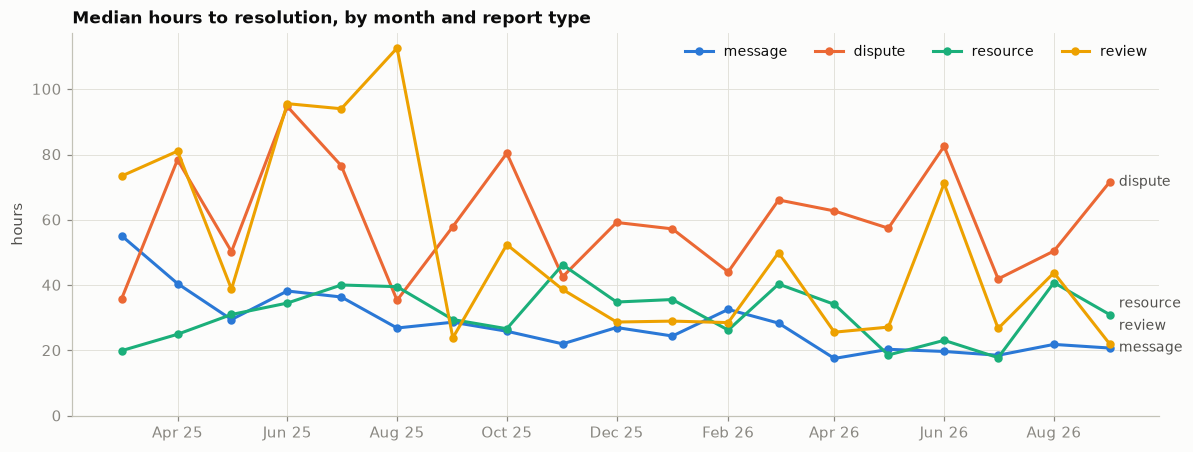

In [5]:
rt = M["resolution_time"].set_index("report_type").reindex(types)
display(rt.round(1))

rtm = M["resolution_time_monthly"]
piv = rtm.pivot_table(index="month", columns="report_type", values="median_hours").sort_index()
fig, ax = plt.subplots(figsize=(11, 4.2))
ends = []
for i, t in enumerate(types):
    if t not in piv.columns:
        continue
    s = piv[t].dropna()
    ax.plot(s.index, s.values, color=SERIES[i], marker="o", markersize=4.5, label=t)
    ends.append([t, s.index[-1], float(s.values[-1])])
# direct labels at the line ends, nudged apart so they never overlap
min_gap = 0.06 * max(1.0, float(np.nanmax(piv.values)))
ends.sort(key=lambda e: e[2])
for k in range(1, len(ends)):
    if ends[k][2] - ends[k - 1][2] < min_gap:
        ends[k][2] = ends[k - 1][2] + min_gap
for t, x, y in ends:
    ax.annotate(t, (x, y), xytext=(6, 0), textcoords="offset points", va="center", color=INK2, fontsize=9)
ax.set_title("Median hours to resolution, by month and report type")
ax.set_ylabel("hours"); ax.set_ylim(bottom=0)
ax.legend(loc="upper right", ncol=4); date_axis(ax, 2)
fig.tight_layout(); plt.show()

## 3. Dismissal rate by reason

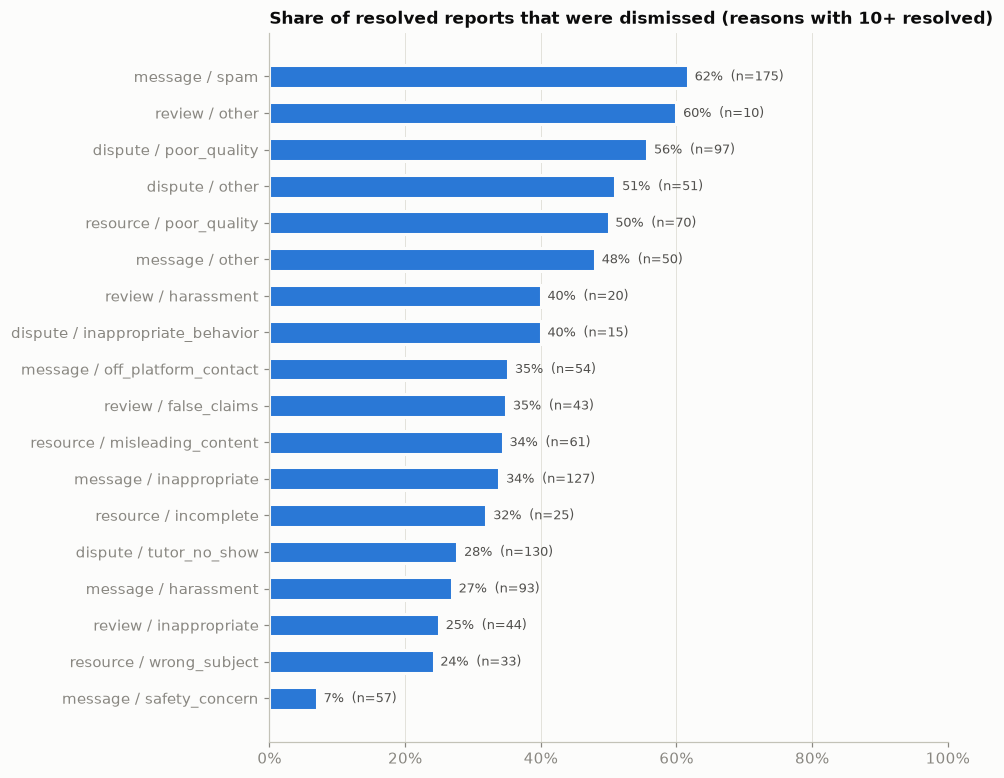

,report_type,reason,reports,resolved,dismissed,actioned,dismissal_rate
9,message,spam,175,175,108,67,0.617
18,review,other,10,10,6,4,0.600
2,dispute,poor_quality,97,97,54,43,0.557
1,dispute,other,52,51,26,25,0.510
13,resource,poor_quality,71,70,35,35,0.500
7,message,other,50,50,24,26,0.480
16,review,harassment,20,20,8,12,0.400
0,dispute,inappropriate_behavior,15,15,6,9,0.400


In [6]:
dr = M["dismissal_rate"].copy()
dr = dr[dr["resolved"] >= 10].sort_values("dismissal_rate")
dr["label"] = dr["report_type"] + " / " + dr["reason"]
fig, ax = plt.subplots(figsize=(9, 0.32 * len(dr) + 1.4))
ax.barh(dr["label"], dr["dismissal_rate"], color=SERIES[0], height=0.62, edgecolor=SURFACE, linewidth=2)
for y, (rate, n) in enumerate(zip(dr["dismissal_rate"], dr["resolved"])):
    ax.text(rate + 0.01, y, f"{rate:.0%}  (n={n})", va="center", color=INK2, fontsize=8.5)
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_title("Share of resolved reports that were dismissed (reasons with 10+ resolved)")
ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()
display(dr[["report_type", "reason", "reports", "resolved", "dismissed", "actioned", "dismissal_rate"]].sort_values("dismissal_rate", ascending=False).head(8))

## 4. Users with two or more reports

In [7]:
ru = M["repeat_reported_users"].sort_values(["actioned", "reports"], ascending=False)
print(f"{len(ru)} users have 2+ reports; {int((ru['reports'] >= 5).sum())} have 5+; {int((ru['actioned'] >= 2).sum())} have 2+ actioned")
cols = [c for c in ["user_id", "user_type", "reports", "report_types", "distinct_reporters", "actioned", "open", "first_reported_at", "last_reported_at"] if c in ru.columns]
display(ru[cols].head(15).reset_index(drop=True))

137 users have 2+ reports; 22 have 5+; 67 have 2+ actioned


,user_id,user_type,reports,report_types,distinct_reporters,actioned,open,first_reported_at,last_reported_at
0,tutor-0003,TUTOR,41,3,34,26,0,2025-05-06 19:13:56.095497+00:00,2026-09-16 15:31:09.961962+00:00
1,tutor-0017,TUTOR,39,3,36,24,0,2025-04-12 03:05:37.365027+00:00,2026-09-14 20:22:22.221997+00:00
2,tutor-0010,TUTOR,34,3,32,23,0,2025-09-17 00:45:01.357362+00:00,2026-09-11 05:49:56.014809+00:00
3,tutor-0007,TUTOR,39,3,39,22,0,2025-03-24 16:48:10.405500+00:00,2026-09-16 00:59:47.346215+00:00
4,tutor-0013,TUTOR,34,3,33,22,0,2025-04-19 06:28:40.035408+00:00,2026-09-15 12:38:15.377073+00:00
5,tutor-0004,TUTOR,31,3,30,22,0,2025-04-09 05:19:12.234026+00:00,2026-09-15 07:57:02.104888+00:00
6,tutor-0012,TUTOR,32,3,29,21,0,2025-03-29 02:13:40.382207+00:00,2026-09-06 14:43:08.077058+00:00
7,tutor-0011,TUTOR,33,3,30,20,0,2025-05-24 15:59:52.327394+00:00,2026-09-15 20:00:04.667954+00:00
8,tutor-0018,TUTOR,27,3,25,20,0,2025-03-20 23:01:16.095314+00:00,2026-08-25 07:20:42.653859+00:00
9,tutor-0001,TUTOR,36,3,33,19,0,2025-04-22 11:43:55.974268+00:00,2026-09-15 11:40:46.244107+00:00


## 5. Garda vetting approval rate

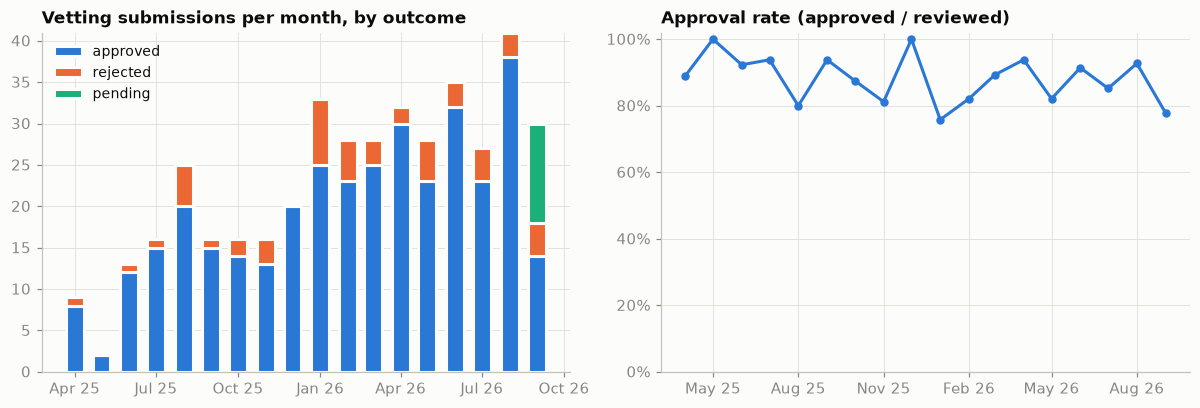

overall approval rate: 87.3%   median review hours (latest month): 35   pending now: 12


In [8]:
va = M["vetting_approval_rate"].sort_values("month")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
bottom = np.zeros(len(va))
for i, (col, name) in enumerate([("approved", "approved"), ("rejected", "rejected"), ("pending", "pending")]):
    a1.bar(va["month"], va[col], bottom=bottom, width=20, color=SERIES[i], label=name, edgecolor=SURFACE, linewidth=2)
    bottom += va[col].values
a1.set_title("Vetting submissions per month, by outcome"); a1.legend(loc="upper left")
a2.plot(va["month"], va["approval_rate"], color=SERIES[0], marker="o", markersize=4.5)
a2.set_ylim(0, 1.02); a2.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
a2.set_title("Approval rate (approved / reviewed)")
date_axis(a1, 3); date_axis(a2, 3)
fig.tight_layout(); plt.show()
print(f"overall approval rate: {va['approved'].sum() / max(1, va['approved'].sum() + va['rejected'].sum()):.1%}   "
      f"median review hours (latest month): {va['median_review_hours'].dropna().iloc[-1]:.0f}   pending now: {int(va['pending'].sum())}")

## 6. Dispute refund rate

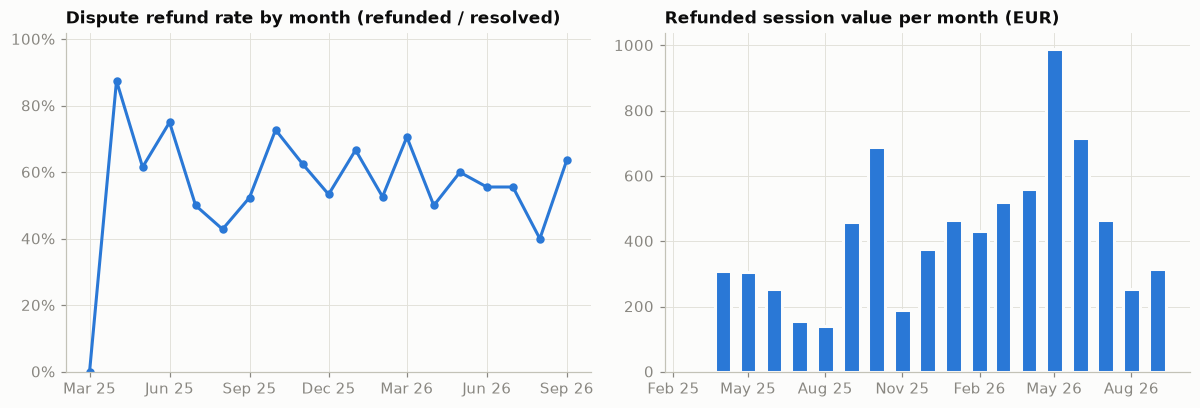

,disputes,refunded,pending,value,refund_rate
reason,,,,,
tutor_no_show,130,94,0,4245.0,0.723
inappropriate_behavior,15,9,0,345.0,0.600
other,52,25,1,1105.0,0.490
poor_quality,97,43,0,1900.0,0.443


In [9]:
dd = M["dispute_refund_rate"].sort_values("month")
overall = dd.groupby("month").agg(disputes=("disputes", "sum"), refunded=("refunded", "sum"), pending=("pending", "sum"), value=("refunded_value_eur", "sum"))
overall["refund_rate"] = overall["refunded"] / (overall["disputes"] - overall["pending"]).replace(0, np.nan)
by_reason = dd.groupby("reason").agg(disputes=("disputes", "sum"), refunded=("refunded", "sum"), pending=("pending", "sum"), value=("refunded_value_eur", "sum"))
by_reason["refund_rate"] = (by_reason["refunded"] / (by_reason["disputes"] - by_reason["pending"]).replace(0, np.nan)).round(3)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(overall.index, overall["refund_rate"], color=SERIES[0], marker="o", markersize=4.5)
a1.set_ylim(0, 1.02); a1.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
a1.set_title("Dispute refund rate by month (refunded / resolved)")
a2.bar(overall.index, overall["value"], width=20, color=SERIES[0], edgecolor=SURFACE, linewidth=2)
a2.set_title("Refunded session value per month (EUR)")
date_axis(a1, 3); date_axis(a2, 3)
fig.tight_layout(); plt.show()
display(by_reason.sort_values("refund_rate", ascending=False))

## 7. Automated screening outcomes (production precision proxy)

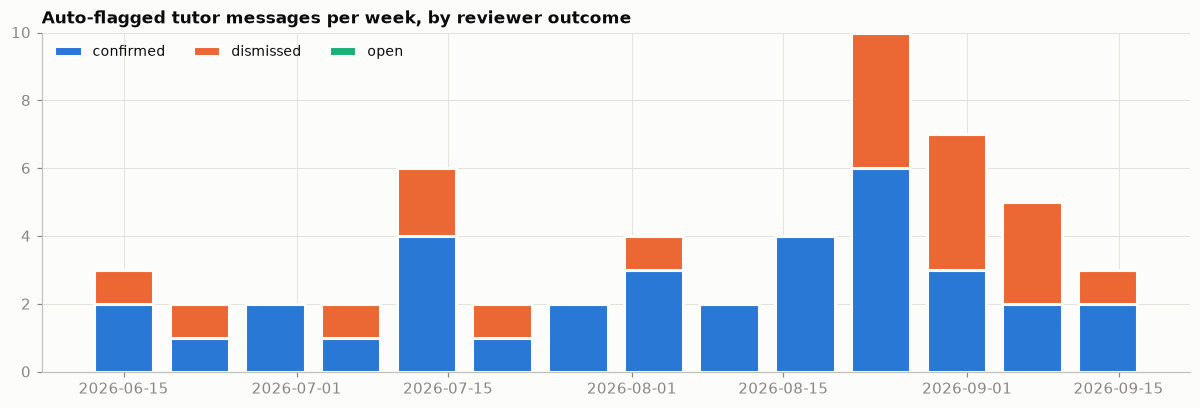

flagged: 54   reviewed: 54   confirmed rate (precision proxy): 64.8%   mean score: 0.73


In [10]:
so = M["screening_outcomes"].sort_values("week_start")
if len(so) == 0:
    print("no automated screening reports yet")
else:
    fig, ax = plt.subplots(figsize=(11, 3.8))
    bottom = np.zeros(len(so))
    for i, col in enumerate(["confirmed", "dismissed", "open"]):
        ax.bar(so["week_start"], so[col], bottom=bottom, width=5.5, color=SERIES[i], label=col, edgecolor=SURFACE, linewidth=2)
        bottom += so[col].values
    ax.set_title("Auto-flagged tutor messages per week, by reviewer outcome"); ax.legend(loc="upper left", ncol=3)
    fig.tight_layout(); plt.show()
    resolved = so["confirmed"].sum() + so["dismissed"].sum()
    print(f"flagged: {int(so['flagged'].sum())}   reviewed: {int(resolved)}   confirmed rate (precision proxy): "
          f"{so['confirmed'].sum() / max(1, resolved):.1%}   mean score: {so['avg_score'].mean():.2f}")

## What we found

In [11]:
total = M["report_volume_weekly"].groupby("week_start")["reports"].sum().sort_index()
first_q, last_q = total.iloc[:13].mean(), total.iloc[-13:].mean()
rt = M["resolution_time"].set_index("report_type")
dr = M["dismissal_rate"]; dr = dr[dr["resolved"] >= 10]
worst = dr.sort_values("dismissal_rate", ascending=False).iloc[0]
best = dr.sort_values("dismissal_rate").iloc[0]
ru = M["repeat_reported_users"]
top_share = ru.sort_values("reports", ascending=False)["reports"].head(20).sum() / max(1, M["report_volume_weekly"]["reports"].sum())
va = M["vetting_approval_rate"]; approval = va["approved"].sum() / max(1, va["approved"].sum() + va["rejected"].sum())
dd = M["dispute_refund_rate"]; refund = dd["refunded"].sum() / max(1, (dd["disputes"] - dd["pending"]).sum())
so = M["screening_outcomes"]; so_res = so["confirmed"].sum() + so["dismissed"].sum() if len(so) else 0
tag = "**Synthetic data - constructed patterns, not findings.**" if SOURCE == "synthetic" else "Real data."

display(Markdown(f'''
{tag}

1. **Volume.** {total.iloc[-13:].sum():.0f} reports in the last 13 weeks, {last_q:.1f}/week versus {first_q:.1f}/week in the first 13
   ({(last_q / max(first_q, 0.1) - 1):+.0%}). Peak week {total.idxmax():%d %b %Y} with {int(total.max())}.
2. **Resolution.** Median hours to resolution: ''' + ", ".join(f"{t} {rt.loc[t, 'median_hours']:.0f}h (p90 {rt.loc[t, 'p90_hours']:.0f}h)" for t in rt.index) + f'''.
   Open backlog: {int(rt["open"].sum())} reports; oldest open {rt["oldest_open_hours"].max():.0f}h.
3. **Dismissals.** Highest dismissal rate: {worst["report_type"]} / {worst["reason"]} at {worst["dismissal_rate"]:.0%} (n={int(worst["resolved"])});
   lowest: {best["report_type"]} / {best["reason"]} at {best["dismissal_rate"]:.0%} (n={int(best["resolved"])}).
4. **Repeat subjects.** {len(ru)} users carry 2+ reports; the 20 most-reported users account for {top_share:.0%} of all reports.
   {int((ru["actioned"] >= 2).sum())} users have 2+ *actioned* reports and are candidates for suspension review.
5. **Vetting.** Approval rate {approval:.0%} over {int(va["submitted"].sum())} submissions; {int(va["pending"].sum())} pending.
6. **Disputes.** Refund rate {refund:.0%} over {int(dd["disputes"].sum())} disputes; EUR {dd["refunded_value_eur"].sum():,.0f} refunded.
7. **Screener.** {int(so["flagged"].sum()) if len(so) else 0} automated flags; reviewer-confirmed rate {(so["confirmed"].sum() / so_res if so_res else float("nan")):.0%} of reviewed.
'''))


**Synthetic data - constructed patterns, not findings.**

1. **Volume.** 252 reports in the last 13 weeks, 19.4/week versus 8.5/week in the first 13
   (+127%). Peak week 11 May 2026 with 40.
2. **Resolution.** Median hours to resolution: dispute 59h (p90 162h), message 24h (p90 63h), resource 32h (p90 76h), review 35h (p90 121h).
   Open backlog: 2 reports; oldest open 65h.
3. **Dismissals.** Highest dismissal rate: message / spam at 62% (n=175);
   lowest: message / safety_concern at 7% (n=57).
4. **Repeat subjects.** 137 users carry 2+ reports; the 20 most-reported users account for 53% of all reports.
   67 users have 2+ *actioned* reports and are candidates for suspension review.
5. **Vetting.** Approval rate 87% over 415 submissions; 12 pending.
6. **Disputes.** Refund rate 58% over 294 disputes; EUR 7,595 refunded.
7. **Screener.** 54 automated flags; reviewer-confirmed rate 65% of reviewed.


### How to read the synthetic run, and what to do with a real one

The synthetic history was built with these patterns on purpose, so seeing them above is a check that the
metrics work, not evidence about the platform: growing volume with September/October and April/May peaks;
resolution times that shorten over the period; spam and "other" mostly dismissed while safety concerns and
harassment are mostly actioned; a heavy tail of repeat-reported tutors; an automated screener that switches
on in the last quarter with roughly a third of its flags dismissed; vetting approvals in the high 80s%; and
tutor-no-show disputes refunded far more often than poor-quality ones.

When the views return real volume (`MIN_REPORTS` or more), the same cells run unchanged and the questions to
ask are:

- **Volume by category and week.** Does a category jump without a matching product change? A spike in
  `safety_concern` or `off_platform_contact` is an escalation trigger on its own; a spike in `spam` usually
  means a reporting-UI or bot problem.
- **Median time to resolution.** Disputes should resolve inside the tutor-response window plus a working day;
  message reports involving a minor should be same-day. Track p90, not just the median - p90 is where the
  unhappy parents live.
- **Dismissal rate by reason.** A reason dismissed more than two-thirds of the time is either mis-labelled by
  the UI or not worth a queue slot; a reason almost never dismissed can probably be auto-escalated.
- **Users with 2+ reports.** Two actioned reports on one account is the suspension-review threshold; the view
  gives distinct reporters so a single feud does not masquerade as a pattern.
- **Vetting approval rate.** A month far below the run-rate means either a document-quality problem (fixable
  with upload guidance) or a fraud wave (not fixable with guidance).
- **Dispute refund rate.** By reason: a rising `tutor_no_show` refund rate is a tutor-reliability problem to
  fix at the source (reminders, reservation limits), not a queue problem.
- **Screening outcomes.** `confirmed_rate` is the screener's production precision. Below ~50% it is wasting
  reviewer time: raise `SCREENING_THRESHOLD` or add the dismissed messages to the labelled set as negatives and
  re-tune. Feed confirmed ones back as positives.